# ODE Baseline Analysis — Ecosystem Simulation Thesis

Classical predator–prey ODE baseline for comparison against the RL-based multi-agent simulation.

**Case studies:** Hudson Bay Hare–Lynx (1900–1920) · Isle Royale Wolf–Moose (1959–2011)

**Models compared:**

| Model | Equations |
|---|---|
| Lotka–Volterra (LV) | $\dot{N} = \alpha N - \beta NP,\quad \dot{P} = \delta\beta NP - \gamma P$ |
| Rosenzweig–MacArthur (RM) | $\dot{N} = rN\bigl(1-\tfrac{N}{K}\bigr) - aNP,\quad \dot{P} = eaNP - dP$ |

RM extends LV by adding a logistic carrying capacity $K$ on prey, matching the `PREY_CARRYING_CAPACITY` constraint in the RL environment.

**Outputs:** fitted parameters, trajectory fits, phase portraits, stability analysis, sensitivity, RL-calibrated forward simulation.

In [21]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution

try:
    import pyreadr
    PYREADR_OK = True
except ImportError:
    PYREADR_OK = False
    print('WARNING: pyreadr not installed — Isle Royale unavailable. pip install pyreadr')

sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')
plt.rcParams['figure.dpi'] = 110

FIGDIR = Path('ode_results')
FIGDIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('../data')
np.random.seed(42)

def savefig(name):
    plt.savefig(FIGDIR / name, bbox_inches='tight', dpi=150)
    print(f'Saved: {FIGDIR / name}')

print('Setup complete.')

Setup complete.


In [22]:
# ── Data loading ──────────────────────────────────────────────────────────────

def load_hare_lynx():
    df = pd.read_csv(DATA_DIR / 'hudson-bay-lynx-hare.csv', comment='#')
    df.columns = df.columns.str.strip()
    df = df.rename(columns={'Year': 'year', 'Lynx': 'predator', 'Hare': 'prey'})
    return df[['year', 'prey', 'predator']].astype(float).reset_index(drop=True)

def load_isle_royale():
    if not PYREADR_OK:
        return None
    result = pyreadr.read_r(DATA_DIR / 'isleRoyal.rda')
    df = result['isleRoyal'][['Year', 'Wolf', 'Moose']].dropna(subset=['Wolf', 'Moose'])
    df.columns = ['year', 'predator', 'prey']
    return df[['year', 'prey', 'predator']].astype(float).reset_index(drop=True)

hare_lynx = load_hare_lynx()
isle_royale = load_isle_royale()

print('Hare-Lynx dataset')
print(f'  Years : {hare_lynx.year.min():.0f}–{hare_lynx.year.max():.0f}  (n={len(hare_lynx)})')
print(f'  Prey  : {hare_lynx.prey.min():.1f}–{hare_lynx.prey.max():.1f} k')
print(f'  Pred  : {hare_lynx.predator.min():.1f}–{hare_lynx.predator.max():.1f} k')

if isle_royale is not None:
    print('\nIsle Royale dataset')
    print(f'  Years : {isle_royale.year.min():.0f}–{isle_royale.year.max():.0f}  (n={len(isle_royale)})')
    print(f'  Prey  : {isle_royale.prey.min():.0f}–{isle_royale.prey.max():.0f} moose')
    print(f'  Pred  : {isle_royale.predator.min():.0f}–{isle_royale.predator.max():.0f} wolves')

Hare-Lynx dataset
  Years : 1900–1920  (n=21)
  Prey  : 7.6–77.4 k
  Pred  : 4.0–59.4 k

Isle Royale dataset
  Years : 1959–2011  (n=53)
  Prey  : 385–2398 moose
  Pred  : 12–50 wolves


Saved: ode_results\raw_data.png


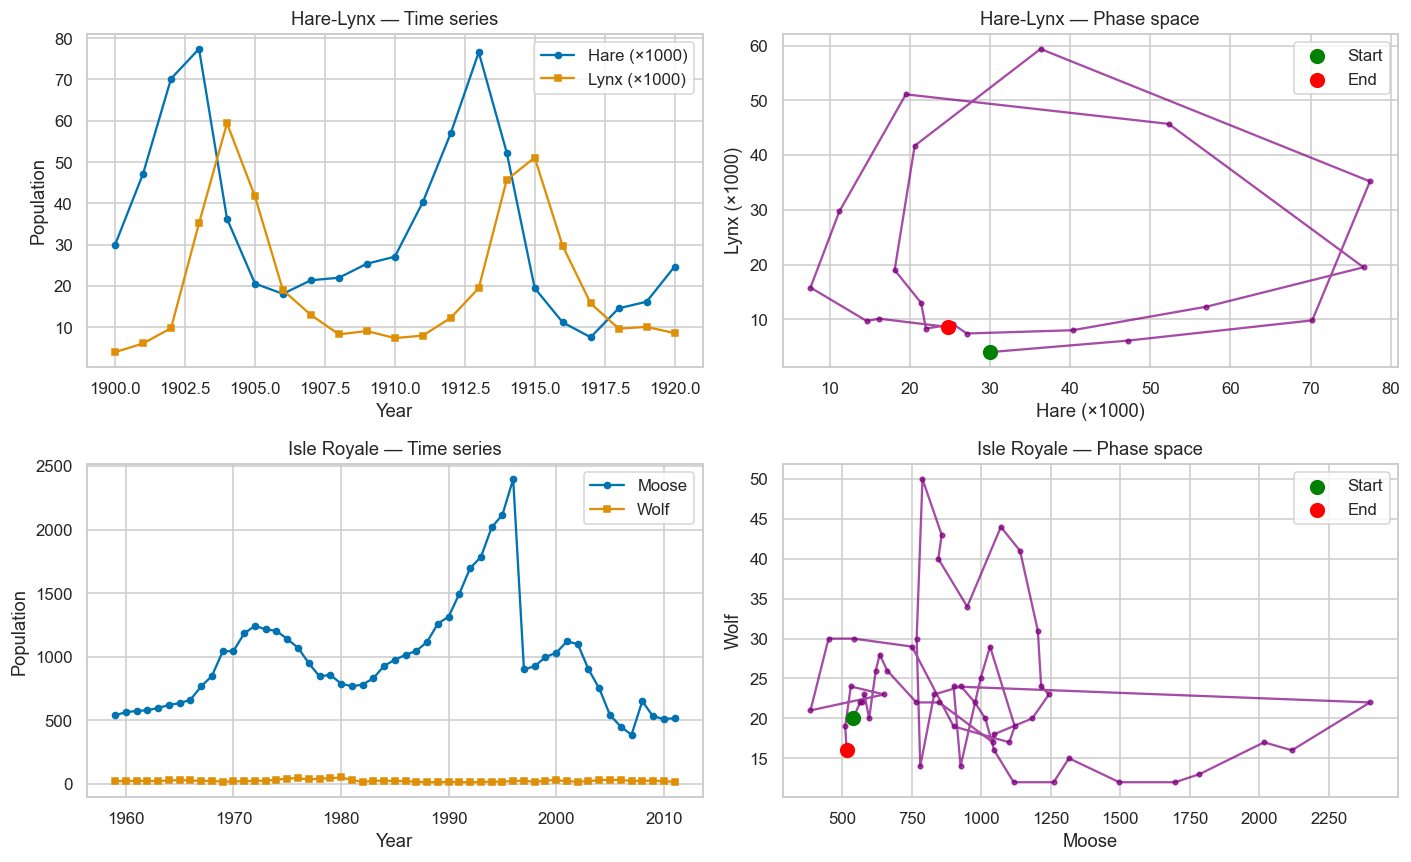

In [23]:
# ── Raw data exploration ───────────────────────────────────────────────────────

n_datasets = 1 + (isle_royale is not None)
fig, axes = plt.subplots(n_datasets, 2, figsize=(13, 4 * n_datasets))
if n_datasets == 1:
    axes = axes[np.newaxis, :]

configs = [
    ('Hare-Lynx', hare_lynx, 'Hare (×1000)', 'Lynx (×1000)'),
]
if isle_royale is not None:
    configs.append(('Isle Royale', isle_royale, 'Moose', 'Wolf'))

colors = sns.color_palette('colorblind')

for row, (name, data, prey_lbl, pred_lbl) in enumerate(configs):
    ax_t = axes[row, 0]
    ax_p = axes[row, 1]

    ax_t.plot(data.year, data.prey, '-o', ms=4, color=colors[0], label=prey_lbl)
    ax_t.plot(data.year, data.predator, '-s', ms=4, color=colors[1], label=pred_lbl)
    ax_t.set_xlabel('Year')
    ax_t.set_ylabel('Population')
    ax_t.set_title(f'{name} — Time series')
    ax_t.legend()

    ax_p.plot(data.prey, data.predator, '-o', ms=3, alpha=0.7, color='purple')
    ax_p.scatter([data.prey.iloc[0]], [data.predator.iloc[0]], color='green',
                 s=80, zorder=6, label='Start')
    ax_p.scatter([data.prey.iloc[-1]], [data.predator.iloc[-1]], color='red',
                 s=80, zorder=6, label='End')
    ax_p.set_xlabel(prey_lbl)
    ax_p.set_ylabel(pred_lbl)
    ax_p.set_title(f'{name} — Phase space')
    ax_p.legend()

plt.tight_layout()
savefig('raw_data.png')
plt.show()

## ODE Models

### Lotka–Volterra
$$\dot{N} = \alpha N - \beta NP \qquad \dot{P} = \delta\beta NP - \gamma P$$
Parameters: $\alpha$ (prey birth), $\beta$ (predation rate), $\delta$ (conversion efficiency), $\gamma$ (predator mortality).  
Coexistence equilibrium: $N^* = \gamma/(\delta\beta),\; P^* = \alpha/\beta$.  
**Eigenvalues are always purely imaginary** → neutral centre, perpetual oscillations.

### Rosenzweig–MacArthur (logistic prey)
$$\dot{N} = rN\!\left(1-\frac{N}{K}\right) - aNP \qquad \dot{P} = eaNP - dP$$
Parameters: $r$ (intrinsic growth), $K$ (carrying capacity), $a$ (attack rate), $e$ (efficiency), $d$ (predator mortality).  
Coexistence equilibrium: $N^* = d/(ea),\; P^* = (r/a)(1 - N^*/K)$.  
**Eigenvalues can have negative real parts** → stable spiral (damped oscillations) or, past the Hopf bifurcation, a stable limit cycle.

In [24]:
# ── ODE definitions and solver ────────────────────────────────────────────────

def lv_ode(t, y, params):
    N, P = max(y[0], 0.0), max(y[1], 0.0)
    alpha, beta, delta, gamma = params
    return [alpha * N - beta * N * P,
            delta * beta * N * P - gamma * P]

def rm_ode(t, y, params):
    N, P = max(y[0], 0.0), max(y[1], 0.0)
    r, K, a, e, d = params
    return [r * N * (1.0 - N / K) - a * N * P,
            e * a * N * P - d * P]

def simulate(ode_fn, y0, t_span, params, n_points=800):
    """Integrate ODE; returns (t, N, P). NaN arrays on solver failure."""
    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    try:
        sol = solve_ivp(
            lambda t, y: ode_fn(t, y, list(params)),
            t_span, list(y0),
            method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-10,
        )
        if sol.success:
            return sol.t, sol.y[0], sol.y[1]
    except Exception:
        pass
    nan = np.full(n_points, np.nan)
    return t_eval, nan, nan.copy()

print('ODE models ready: lv_ode, rm_ode')

ODE models ready: lv_ode, rm_ode


In [25]:
# ── Fitting infrastructure ────────────────────────────────────────────────────

def _make_objective(ode_fn, t_data, N_obs, P_obs, y0):
    t_span = (t_data[0], t_data[-1])
    N_sc = np.mean(N_obs)
    P_sc = np.mean(P_obs)

    def objective(params):
        t, N, P = simulate(ode_fn, y0, t_span, params, n_points=len(t_data) * 8)
        if np.any(np.isnan(N)):
            return 1e10
        N_s = np.clip(np.interp(t_data, t, N), 0, None)
        P_s = np.clip(np.interp(t_data, t, P), 0, None)
        return (np.mean(((N_s - N_obs) / N_sc) ** 2) +
                np.mean(((P_s - P_obs) / P_sc) ** 2))
    return objective

def fit_model(ode_fn, data, bounds):
    """Fit ODE to data via differential evolution. Returns (params, prey_rmse, pred_rmse)."""
    t = (data.year.values - data.year.values[0]).astype(float)
    N_obs, P_obs = data.prey.values, data.predator.values
    y0 = [float(N_obs[0]), float(P_obs[0])]
    obj = _make_objective(ode_fn, t, N_obs, P_obs, y0)

    res = differential_evolution(
        obj, bounds, seed=42, maxiter=800, tol=1e-9,
        popsize=18, mutation=(0.5, 1.5), recombination=0.7, workers=1,
    )
    params = list(res.x)

    t_sim, N_sim, P_sim = simulate(ode_fn, y0, (t[0], t[-1]), params)
    N_fit = np.interp(t, t_sim, N_sim)
    P_fit = np.interp(t, t_sim, P_sim)
    rmse_N = float(np.sqrt(np.mean((N_fit - N_obs) ** 2)))
    rmse_P = float(np.sqrt(np.mean((P_fit - P_obs) ** 2)))
    return params, rmse_N, rmse_P

def aic(n, k, rmse_N, rmse_P):
    rss = (rmse_N ** 2 + rmse_P ** 2) * n
    return n * np.log(rss / n) + 2 * k

print('Fitting infrastructure ready.')

Fitting infrastructure ready.


In [26]:
# ── Fit both models to Hare-Lynx ──────────────────────────────────────────────
# Population is in thousands; periods ~10 years; time unit = 1 year.

print('Fitting LV to Hare-Lynx...')
lv_bounds_hl = [(0.1, 5.0), (0.005, 2.0), (0.005, 1.0), (0.1, 5.0)]
lv_p_hl, lv_rN_hl, lv_rP_hl = fit_model(lv_ode, hare_lynx, lv_bounds_hl)
print(f'  α={lv_p_hl[0]:.4f}  β={lv_p_hl[1]:.4f}  δ={lv_p_hl[2]:.4f}  γ={lv_p_hl[3]:.4f}')
print(f'  RMSE prey={lv_rN_hl:.3f}  predator={lv_rP_hl:.3f}')

print('\nFitting RM to Hare-Lynx...')
rm_bounds_hl = [(0.1, 5.0), (20.0, 600.0), (0.001, 2.0), (0.001, 1.0), (0.1, 5.0)]
rm_p_hl, rm_rN_hl, rm_rP_hl = fit_model(rm_ode, hare_lynx, rm_bounds_hl)
print(f'  r={rm_p_hl[0]:.4f}  K={rm_p_hl[1]:.2f}  a={rm_p_hl[2]:.4f}  e={rm_p_hl[3]:.4f}  d={rm_p_hl[4]:.4f}')
print(f'  RMSE prey={rm_rN_hl:.3f}  predator={rm_rP_hl:.3f}')

Fitting LV to Hare-Lynx...
  α=0.5669  β=0.0291  δ=0.9014  γ=0.8082
  RMSE prey=5.205  predator=3.318

Fitting RM to Hare-Lynx...
  r=0.6530  K=600.00  a=0.0295  e=0.8181  d=0.7274
  RMSE prey=5.627  predator=3.484


In [27]:
# ── Fit both models to Isle Royale ────────────────────────────────────────────
# NOTE: Isle Royale dynamics are strongly influenced by disease (canine parvovirus ~1980)
# and inbreeding depression; ODE fits should be interpreted as rough structural matches.

lv_p_ir = rm_p_ir = None
lv_rN_ir = lv_rP_ir = rm_rN_ir = rm_rP_ir = None

if isle_royale is not None:
    print('Fitting LV to Isle Royale...')
    lv_bounds_ir = [(0.01, 1.0), (0.00001, 0.01), (0.0001, 0.5), (0.01, 1.0)]
    lv_p_ir, lv_rN_ir, lv_rP_ir = fit_model(lv_ode, isle_royale, lv_bounds_ir)
    print(f'  α={lv_p_ir[0]:.5f}  β={lv_p_ir[1]:.6f}  δ={lv_p_ir[2]:.5f}  γ={lv_p_ir[3]:.5f}')
    print(f'  RMSE prey={lv_rN_ir:.2f}  predator={lv_rP_ir:.2f}')

    print('\nFitting RM to Isle Royale...')
    rm_bounds_ir = [(0.01, 1.0), (500.0, 5000.0), (0.000001, 0.01), (0.0001, 0.5), (0.01, 1.0)]
    rm_p_ir, rm_rN_ir, rm_rP_ir = fit_model(rm_ode, isle_royale, rm_bounds_ir)
    print(f'  r={rm_p_ir[0]:.5f}  K={rm_p_ir[1]:.1f}  a={rm_p_ir[2]:.6f}  e={rm_p_ir[3]:.5f}  d={rm_p_ir[4]:.5f}')
    print(f'  RMSE prey={rm_rN_ir:.2f}  predator={rm_rP_ir:.2f}')

Fitting LV to Isle Royale...
  α=0.22543  β=0.010000  δ=0.03412  γ=0.30062
  RMSE prey=336.91  predator=7.63

Fitting RM to Isle Royale...
  r=0.24398  K=5000.0  a=0.008499  e=0.04291  d=0.35067
  RMSE prey=342.95  predator=7.10


In [28]:
# ── Model comparison table ────────────────────────────────────────────────────

rows = [
    {'Dataset': 'Hare-Lynx', 'Model': 'Lotka-Volterra',      'k': 4,
     'RMSE prey': lv_rN_hl, 'RMSE pred': lv_rP_hl,
     'AIC': aic(len(hare_lynx), 4, lv_rN_hl, lv_rP_hl)},
    {'Dataset': 'Hare-Lynx', 'Model': 'Rosenzweig-MacArthur','k': 5,
     'RMSE prey': rm_rN_hl, 'RMSE pred': rm_rP_hl,
     'AIC': aic(len(hare_lynx), 5, rm_rN_hl, rm_rP_hl)},
]
if isle_royale is not None:
    rows += [
        {'Dataset': 'Isle Royale', 'Model': 'Lotka-Volterra',      'k': 4,
         'RMSE prey': lv_rN_ir, 'RMSE pred': lv_rP_ir,
         'AIC': aic(len(isle_royale), 4, lv_rN_ir, lv_rP_ir)},
        {'Dataset': 'Isle Royale', 'Model': 'Rosenzweig-MacArthur','k': 5,
         'RMSE prey': rm_rN_ir, 'RMSE pred': rm_rP_ir,
         'AIC': aic(len(isle_royale), 5, rm_rN_ir, rm_rP_ir)},
    ]

cmp_df = pd.DataFrame(rows)
print('=== Model Comparison ===')
print(cmp_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
cmp_df.to_csv(FIGDIR / 'model_comparison.csv', index=False)

=== Model Comparison ===
    Dataset                Model  k  RMSE prey  RMSE pred     AIC
  Hare-Lynx       Lotka-Volterra  4      5.205      3.318  84.443
  Hare-Lynx Rosenzweig-MacArthur  5      5.627      3.484  89.373
Isle Royale       Lotka-Volterra  4    336.913      7.635 624.929
Isle Royale Rosenzweig-MacArthur  5    342.952      7.096 628.807


Saved: ode_results\trajectory_fit.png


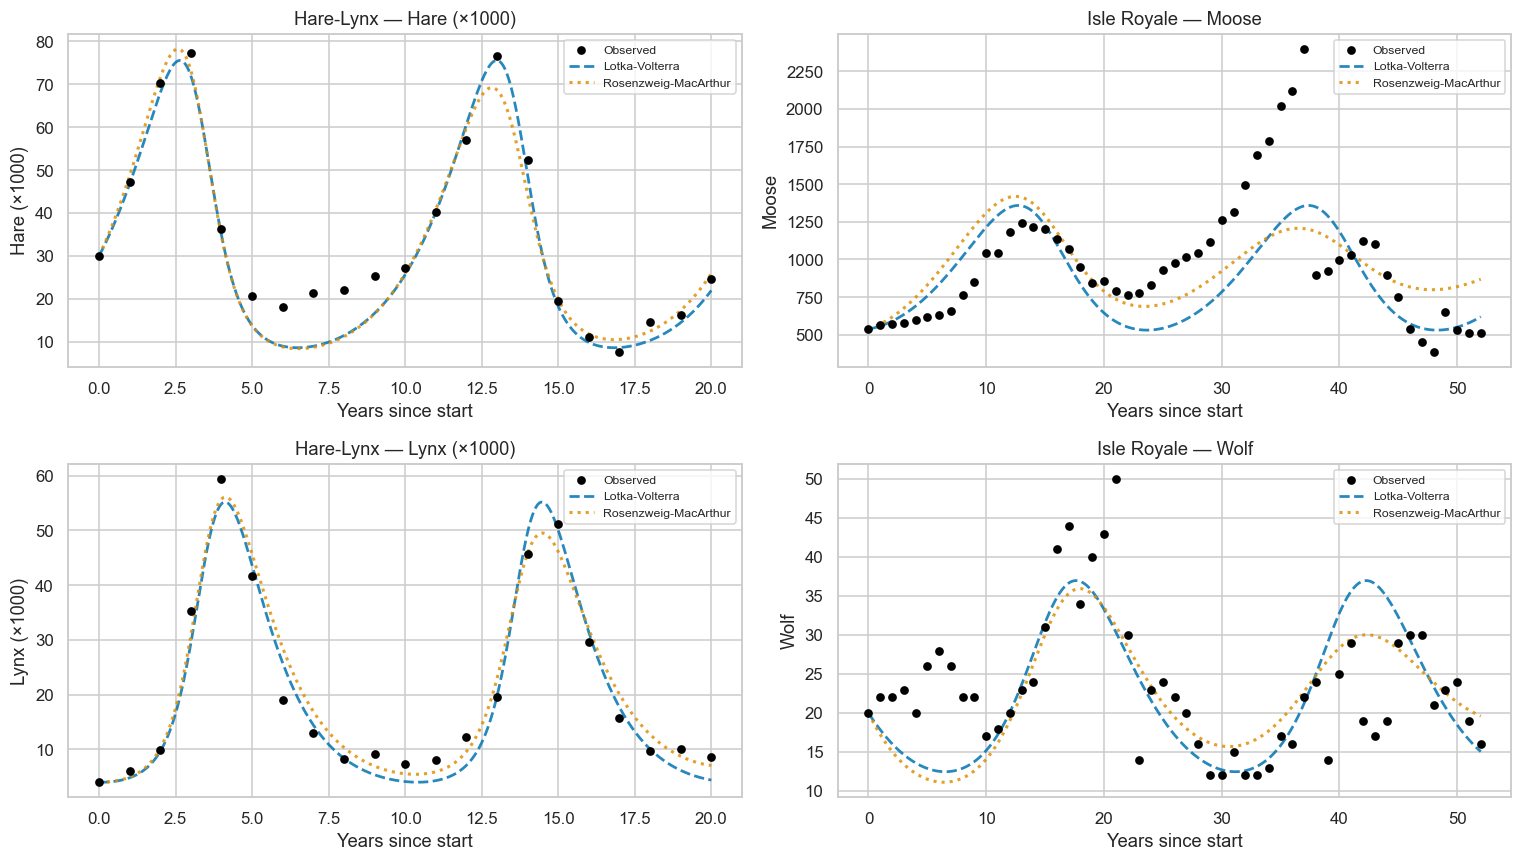

In [29]:
# ── Trajectory plots: fitted models vs observed data ─────────────────────────

datasets_plot = [('Hare-Lynx', hare_lynx, 'Hare (×1000)', 'Lynx (×1000)', lv_p_hl, rm_p_hl)]
if isle_royale is not None:
    datasets_plot.append(('Isle Royale', isle_royale, 'Moose', 'Wolf', lv_p_ir, rm_p_ir))

nc = len(datasets_plot)
fig, axes = plt.subplots(2, nc, figsize=(7 * nc, 8))
if nc == 1:
    axes = axes[:, np.newaxis]

for col, (name, data, prey_lbl, pred_lbl, lv_p, rm_p) in enumerate(datasets_plot):
    t_data = (data.year.values - data.year.values[0]).astype(float)
    t_span = (0.0, t_data[-1])
    y0 = [float(data.prey.values[0]), float(data.predator.values[0])]

    t_lv, N_lv, P_lv = simulate(lv_ode, y0, t_span, lv_p)
    t_rm, N_rm, P_rm = simulate(rm_ode, y0, t_span, rm_p)

    for row, (obs, y_lv, y_rm, label) in enumerate([
        (data.prey.values,      N_lv, N_rm, prey_lbl),
        (data.predator.values,  P_lv, P_rm, pred_lbl),
    ]):
        ax = axes[row, col]
        ax.scatter(t_data, obs, c='black', s=22, zorder=5, label='Observed')
        ax.plot(t_lv, y_lv, '--', lw=1.8, label='Lotka-Volterra', alpha=0.85)
        ax.plot(t_rm, y_rm, ':',  lw=2.0, label='Rosenzweig-MacArthur', alpha=0.85)
        ax.set_xlabel('Years since start')
        ax.set_ylabel(label)
        ax.set_title(f'{name} — {label}')
        ax.legend(fontsize=8)

plt.tight_layout()
savefig('trajectory_fit.png')
plt.show()

Saved: ode_results\phase_portraits.png


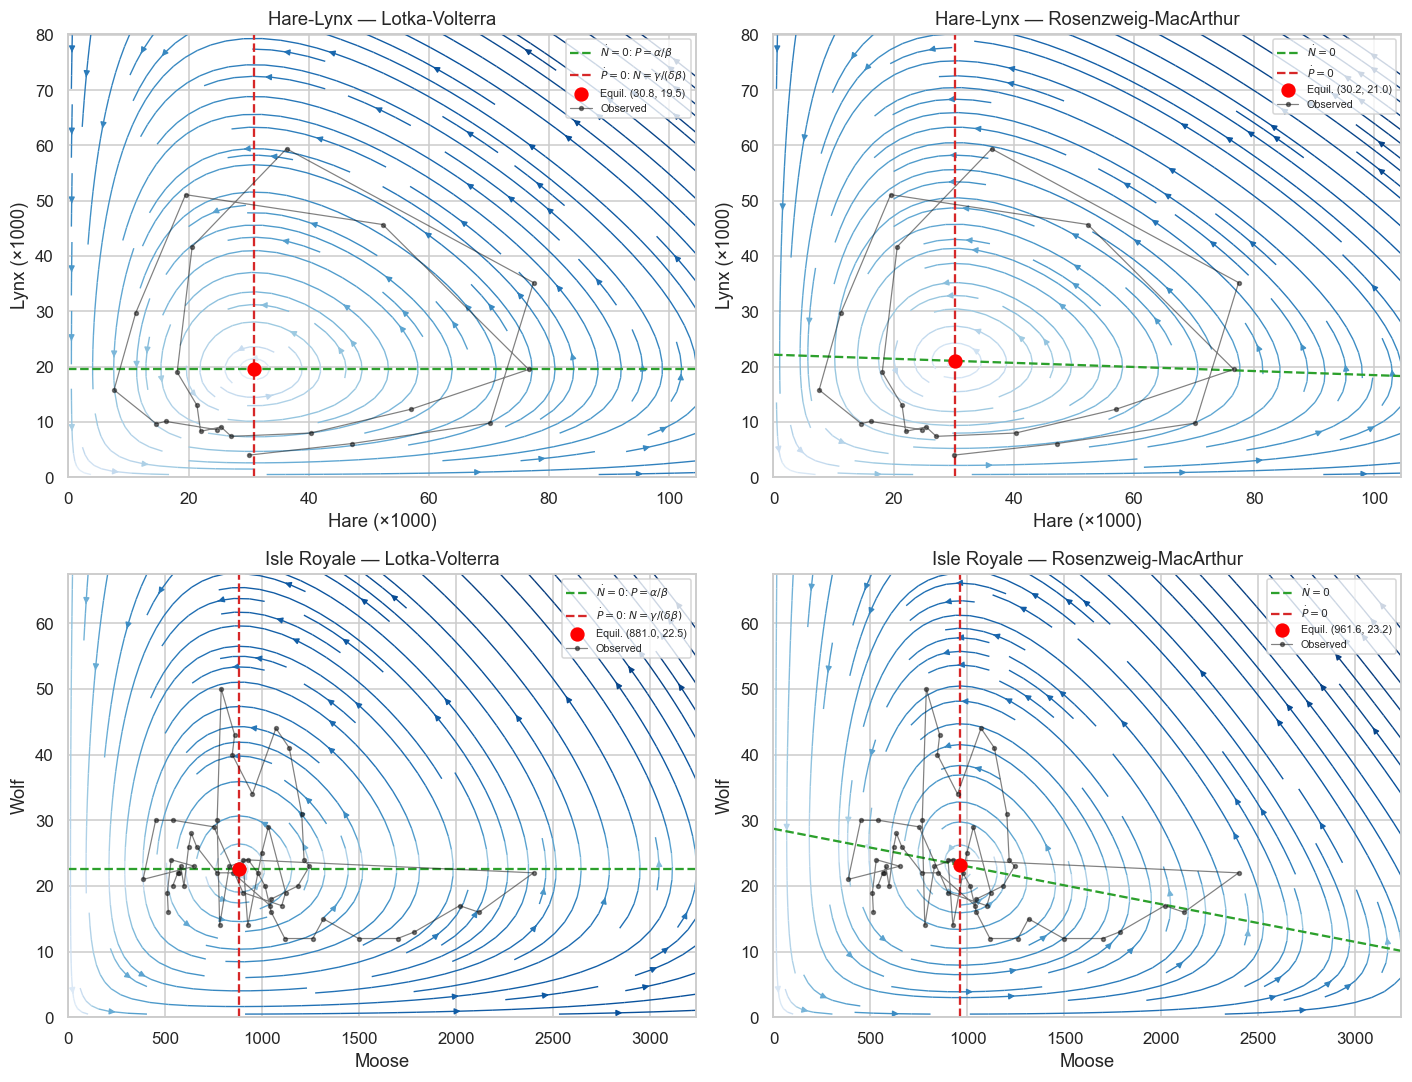

In [30]:
# ── Phase portraits & nullclines ──────────────────────────────────────────────
# 2×2 grid: rows = dataset, cols = LV / RM

def phase_portrait(ax, ode_fn, params, data, prey_lbl, pred_lbl, title):
    N_max = data.prey.max() * 1.35
    P_max = data.predator.max() * 1.35
    Ng = np.linspace(0.5, N_max, 22)
    Pg = np.linspace(0.5, P_max, 22)
    NN, PP = np.meshgrid(Ng, Pg)
    dN = np.zeros_like(NN)
    dP = np.zeros_like(PP)
    for i in range(NN.shape[0]):
        for j in range(NN.shape[1]):
            dN[i,j], dP[i,j] = ode_fn(0, [NN[i,j], PP[i,j]], params)
    speed = np.sqrt(dN**2 + dP**2) + 1e-9
    ax.streamplot(Ng, Pg, dN, dP, color=np.log1p(speed), cmap='Blues',
                  density=1.1, linewidth=0.9, arrowsize=0.8)

    # Nullclines
    Nline = np.linspace(0.1, N_max, 400)
    if len(params) == 4:  # LV
        alpha, beta, delta, gamma = params
        ax.axhline(alpha / beta, color='tab:green', ls='--', lw=1.5,
                   label=r'$\dot{N}=0$: $P=\alpha/\beta$')
        ax.axvline(gamma / (delta * beta), color='tab:red', ls='--', lw=1.5,
                   label=r'$\dot{P}=0$: $N=\gamma/(\delta\beta)$')
        N_eq = gamma / (delta * beta)
        P_eq = alpha / beta
    else:  # RM
        r, K, a, e, d = params
        prey_null = r / a * (1.0 - Nline / K)
        ax.plot(Nline, prey_null, color='tab:green', ls='--', lw=1.5,
                label=r'$\dot{N}=0$')
        N_eq = d / (e * a)
        P_eq = r / a * (1.0 - N_eq / K)
        ax.axvline(N_eq, color='tab:red', ls='--', lw=1.5, label=r'$\dot{P}=0$')

    if 0 < N_eq < N_max and 0 < P_eq < P_max:
        ax.scatter([N_eq], [P_eq], color='red', s=70, zorder=7,
                   label=f'Equil. ({N_eq:.1f}, {P_eq:.1f})')

    ax.plot(data.prey.values, data.predator.values, 'ko-', ms=2.5,
            alpha=0.55, lw=0.8, label='Observed')
    ax.set_xlim(0, N_max)
    ax.set_ylim(0, P_max)
    ax.set_xlabel(prey_lbl)
    ax.set_ylabel(pred_lbl)
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right')

fig, axes = plt.subplots(n_datasets, 2, figsize=(13, 5 * n_datasets))
if n_datasets == 1:
    axes = axes[np.newaxis, :]

portrait_configs = [
    ('Hare-Lynx', hare_lynx, 'Hare (×1000)', 'Lynx (×1000)', lv_p_hl, rm_p_hl),
]
if isle_royale is not None:
    portrait_configs.append(
        ('Isle Royale', isle_royale, 'Moose', 'Wolf', lv_p_ir, rm_p_ir)
    )

for row, (name, data, pl, prl, lv_p, rm_p) in enumerate(portrait_configs):
    phase_portrait(axes[row, 0], lv_ode, lv_p, data, pl, prl, f'{name} — Lotka-Volterra')
    phase_portrait(axes[row, 1], rm_ode, rm_p, data, pl, prl, f'{name} — Rosenzweig-MacArthur')

plt.tight_layout()
savefig('phase_portraits.png')
plt.show()

In [31]:
# ── Stability analysis at coexistence equilibrium ─────────────────────────────

def lv_jacobian(N_eq, P_eq, p):
    alpha, beta, delta, gamma = p
    return np.array([[alpha - beta*P_eq,   -beta*N_eq],
                     [delta*beta*P_eq,      delta*beta*N_eq - gamma]])

def rm_jacobian(N_eq, P_eq, p):
    r, K, a, e, d = p
    return np.array([[r*(1 - 2*N_eq/K) - a*P_eq,  -a*N_eq],
                     [e*a*P_eq,                     e*a*N_eq - d]])

def stability_report(name, lv_p, rm_p):
    print(f'--- {name} ---')
    # LV
    alpha, beta, delta, gamma = lv_p
    N_lv = gamma / (delta * beta)
    P_lv = alpha / beta
    eigs_lv = np.linalg.eigvals(lv_jacobian(N_lv, P_lv, lv_p))
    print(f'  LV  N*={N_lv:.3f}  P*={P_lv:.3f}')
    print(f'      λ = {eigs_lv[0]:.4f}, {eigs_lv[1]:.4f}')
    print(f'      Re(λ) ≈ 0  →  neutrally stable centre (perpetual oscillations)')
    # RM
    r, K, a, e, d = rm_p
    N_rm = d / (e * a)
    P_rm = r / a * (1 - N_rm / K)
    feasible = (0 < N_rm < K) and (P_rm > 0)
    if feasible:
        eigs_rm = np.linalg.eigvals(rm_jacobian(N_rm, P_rm, rm_p))
        re = np.real(eigs_rm)
        im = np.imag(eigs_rm)
        stability = ('stable spiral' if np.all(re < 0) and np.any(im != 0)
                     else 'stable node' if np.all(re < 0)
                     else 'unstable (limit cycle expected)')
        print(f'  RM  N*={N_rm:.3f}  P*={P_rm:.3f}')
        print(f'      λ = {eigs_rm[0]:.4f}, {eigs_rm[1]:.4f}')
        print(f'      Re(λ) = {re[0]:.4f}, {re[1]:.4f}  →  {stability}')
    else:
        print(f'  RM  N*={N_rm:.3f}  P*={P_rm:.4f}  →  not biologically feasible')
    print()

print('=== Stability Analysis at Coexistence Equilibrium ===\n')
stability_report('Hare-Lynx', lv_p_hl, rm_p_hl)
if isle_royale is not None:
    stability_report('Isle Royale', lv_p_ir, rm_p_ir)

=== Stability Analysis at Coexistence Equilibrium ===

--- Hare-Lynx ---
  LV  N*=30.841  P*=19.501
      λ = 0.0000+0.6769j, 0.0000-0.6769j
      Re(λ) ≈ 0  →  neutrally stable centre (perpetual oscillations)
  RM  N*=30.178  P*=21.048
      λ = -0.0164+0.6714j, -0.0164-0.6714j
      Re(λ) = -0.0164, -0.0164  →  stable spiral

--- Isle Royale ---
  LV  N*=880.968  P*=22.543
      λ = 0.0000+0.2603j, 0.0000-0.2603j
      Re(λ) ≈ 0  →  neutrally stable centre (perpetual oscillations)
  RM  N*=961.601  P*=23.185
      λ = -0.0235+0.2618j, -0.0235-0.2618j
      Re(λ) = -0.0235, -0.0235  →  stable spiral



--- Hare-Lynx RM sensitivity (+10%) ---
Parameter  ΔN* (%)  ΔP* (%)
        r     +0.0    +10.0
        K     +0.0     +0.5
        a     -9.1     -8.7
        e     -9.1     +0.5
        d    +10.0     -0.5

--- Isle Royale RM sensitivity (+10%) ---
Parameter  ΔN* (%)  ΔP* (%)
        r     +0.0    +10.0
        K     +0.0     +2.2
        a     -9.1     -7.1
        e     -9.1     +2.2
        d    +10.0     -2.4

Saved: ode_results\sensitivity.png


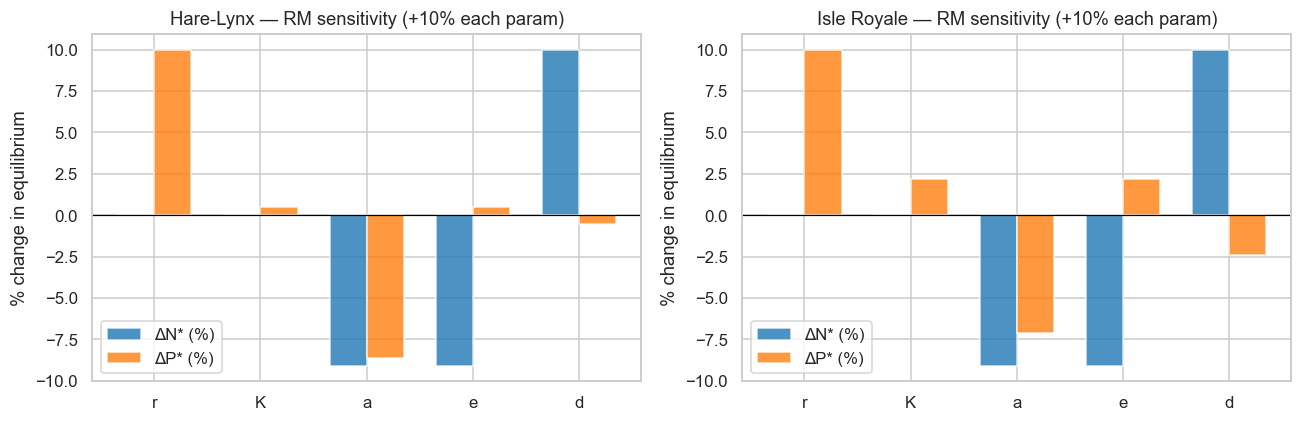

In [32]:
# ── Parameter sensitivity — RM model ─────────────────────────────────────────
# Perturb each parameter +10%; measure % change in coexistence equilibrium.

def rm_equilibrium(p):
    r, K, a, e, d = p
    N_eq = d / (e * a)
    P_eq = r / a * (1.0 - N_eq / K) if N_eq < K else 0.0
    return N_eq, P_eq

def sensitivity_table(base, names, perturb=0.10):
    N0, P0 = rm_equilibrium(base)
    rows = []
    for i, nm in enumerate(names):
        p = list(base)
        p[i] *= (1 + perturb)
        N1, P1 = rm_equilibrium(p)
        rows.append({'Parameter': nm,
                     'ΔN* (%)': (N1-N0)/N0*100 if N0 else float('nan'),
                     'ΔP* (%)': (P1-P0)/P0*100 if P0 else float('nan')})
    return pd.DataFrame(rows)

rm_names = ['r', 'K', 'a', 'e', 'd']

fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 4), sharey=False)
if n_datasets == 1:
    axes = [axes]

sens_configs = [('Hare-Lynx', rm_p_hl)]
if isle_royale is not None:
    sens_configs.append(('Isle Royale', rm_p_ir))

for ax, (name, rm_p) in zip(axes, sens_configs):
    df_s = sensitivity_table(rm_p, rm_names)
    print(f'--- {name} RM sensitivity (+10%) ---')
    print(df_s.to_string(index=False, float_format=lambda x: f'{x:+.1f}'))
    print()
    df_s.to_csv(FIGDIR / f'sensitivity_{name.lower().replace(" ","_")}.csv', index=False)

    colors_bar = ['tab:blue' if v >= 0 else 'tab:orange' for v in df_s['ΔN* (%)']]
    x = np.arange(len(rm_names))
    w = 0.35
    bars1 = ax.bar(x - w/2, df_s['ΔN* (%)'], w, label='ΔN* (%)', color='tab:blue', alpha=0.8)
    bars2 = ax.bar(x + w/2, df_s['ΔP* (%)'], w, label='ΔP* (%)', color='tab:orange', alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(rm_names)
    ax.set_ylabel('% change in equilibrium')
    ax.set_title(f'{name} — RM sensitivity (+10% each param)')
    ax.legend()

plt.tight_layout()
savefig('sensitivity.png')
plt.show()

RL-calibrated RM parameters (per episode):
  r = 0.4000
  K = 337.0000
  a = 0.6283
  e = 0.1000
  d = 0.7059

Coexistence equilibrium: N*=11.2  P*=0.6
Eigenvalues: -0.0067+0.5224j,  -0.0067-0.5224j
Re(λ) = -0.0067, -0.0067
Saved: ode_results\rl_calibrated.png


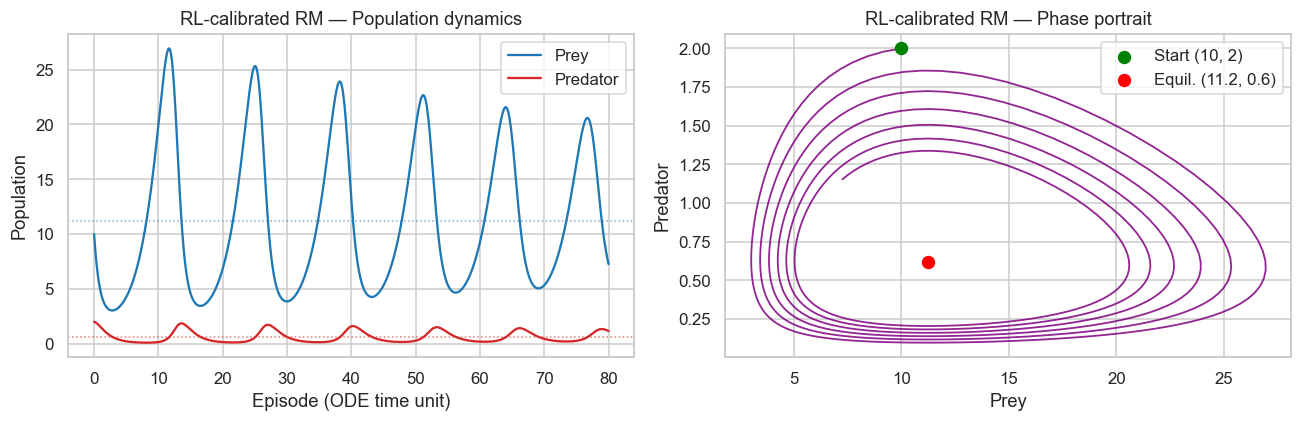

In [33]:
# ── RL-calibrated forward simulation ─────────────────────────────────────────
# Translate ecoSim config.py parameters into RM-equivalent values.
# Time unit = 1 RL episode (500 steps).

GRID_CELLS      = 150 * 150           # 22500
STEPS_EP        = 500
ENERGY_DECAY    = 0.12                # per step
MAX_ENERGY      = 100.0
GRASS_ENERGY    = 40.0
GRASS_COVERAGE  = 0.8
ACTION_RADIUS   = 3
K_rl            = int(GRID_CELLS * 0.015)   # PREY_CARRYING_CAPACITY = 337

# r: prey intrinsic growth (per episode)
# cooldown=8 steps → max ~62 reproduction chances/episode × prob_scale=0.8
r_rl = 0.40  # conservative; real value depends on energy distribution

# a: attack rate  ≈ (area swept per step * steps) / grid
import math
a_rl = (math.pi * ACTION_RADIUS**2 / GRID_CELLS) * STEPS_EP   # ≈ 0.063

# e: conversion efficiency  ≈ (energy from hunt) / MAX_ENERGY
e_rl = 0.25 * GRASS_ENERGY / MAX_ENERGY   # = 0.10

# d: predator mortality per episode  ≈ decay * steps / start_energy
d_rl = ENERGY_DECAY * STEPS_EP / 85.0    # ≈ 0.71

rl_params = [r_rl, float(K_rl), a_rl, e_rl, d_rl]
print('RL-calibrated RM parameters (per episode):')
for nm, val in zip(['r', 'K', 'a', 'e', 'd'], rl_params):
    print(f'  {nm} = {val:.4f}')

N_eq_rl = d_rl / (e_rl * a_rl)
P_eq_rl = r_rl / a_rl * (1 - N_eq_rl / K_rl)
print(f'\nCoexistence equilibrium: N*={N_eq_rl:.1f}  P*={P_eq_rl:.1f}')

J_rl   = rm_jacobian(N_eq_rl, P_eq_rl, rl_params)
eigs_rl = np.linalg.eigvals(J_rl)
print(f'Eigenvalues: {eigs_rl[0]:.4f},  {eigs_rl[1]:.4f}')
print(f'Re(λ) = {np.real(eigs_rl[0]):.4f}, {np.real(eigs_rl[1]):.4f}')

# Forward simulation from typical RL starting conditions
y0_rl = [10.0, 2.0]   # matches NUM_AGENTS=10, rough prey/predator split
t_rl, N_rl, P_rl = simulate(rm_ode, y0_rl, (0, 80), rl_params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t_rl, N_rl, label='Prey', color='tab:blue')
ax1.plot(t_rl, P_rl, label='Predator', color='tab:red')
ax1.axhline(N_eq_rl, color='tab:blue', ls=':', lw=1, alpha=0.6)
ax1.axhline(P_eq_rl, color='tab:red',  ls=':', lw=1, alpha=0.6)
ax1.set_xlabel('Episode (ODE time unit)')
ax1.set_ylabel('Population')
ax1.set_title('RL-calibrated RM — Population dynamics')
ax1.legend()

ax2.plot(N_rl, P_rl, alpha=0.85, color='purple', lw=1.2)
ax2.scatter([N_rl[0]], [P_rl[0]], color='green', s=60, zorder=5, label='Start (10, 2)')
ax2.scatter([N_eq_rl], [P_eq_rl], color='red', s=60, zorder=5, label=f'Equil. ({N_eq_rl:.1f}, {P_eq_rl:.1f})')
ax2.set_xlabel('Prey')
ax2.set_ylabel('Predator')
ax2.set_title('RL-calibrated RM — Phase portrait')
ax2.legend()

plt.tight_layout()
savefig('rl_calibrated.png')
plt.show()

In [34]:
# ── Export all fitted parameters and trajectories ─────────────────────────────

export = {
    'hare_lynx': {
        'lv': {'params': dict(zip(['alpha','beta','delta','gamma'], lv_p_hl)),
               'rmse_prey': lv_rN_hl, 'rmse_pred': lv_rP_hl},
        'rm': {'params': dict(zip(['r','K','a','e','d'], rm_p_hl)),
               'rmse_prey': rm_rN_hl, 'rmse_pred': rm_rP_hl},
    },
    'rl_calibrated': {
        'rm': {'params': dict(zip(['r','K','a','e','d'], rl_params)),
               'equilibrium': {'N_star': N_eq_rl, 'P_star': P_eq_rl}}
    },
}
if isle_royale is not None:
    export['isle_royale'] = {
        'lv': {'params': dict(zip(['alpha','beta','delta','gamma'], lv_p_ir)),
               'rmse_prey': lv_rN_ir, 'rmse_pred': lv_rP_ir},
        'rm': {'params': dict(zip(['r','K','a','e','d'], rm_p_ir)),
               'rmse_prey': rm_rN_ir, 'rmse_pred': rm_rP_ir},
    }

with open(FIGDIR / 'fitted_parameters.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Exported: ode_results/fitted_parameters.json')

# Trajectory CSVs for future RL comparison
traj_configs = [('hare_lynx', hare_lynx, lv_p_hl, rm_p_hl)]
if isle_royale is not None:
    traj_configs.append(('isle_royale', isle_royale, lv_p_ir, rm_p_ir))

for ds_name, data, lv_p, rm_p in traj_configs:
    t0 = float(data.year.values[0])
    tf = float(data.year.values[-1])
    y0 = [float(data.prey.values[0]), float(data.predator.values[0])]
    for mname, mfn, mp in [('lv', lv_ode, lv_p), ('rm', rm_ode, rm_p)]:
        t, N, P = simulate(mfn, y0, (0.0, tf - t0), mp)
        pd.DataFrame({'time': t, 'prey': N, 'predator': P}).to_csv(
            FIGDIR / f'trajectory_{ds_name}_{mname}.csv', index=False)

# RL-calibrated trajectory
pd.DataFrame({'episode': t_rl, 'prey_ode': N_rl, 'predator_ode': P_rl}).to_csv(
    FIGDIR / 'trajectory_rl_calibrated_rm.csv', index=False)

print('Exported trajectory CSVs to ode_results/')
print('\nAll done.')

Exported: ode_results/fitted_parameters.json
Exported trajectory CSVs to ode_results/

All done.
